#Загрузка данных

In [90]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# добавление доп библиотек
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
!pip install mlflow
import mlflow
import mlflow.sklearn
!pip install xgboost -q

uploaded = files.upload()
df = pd.read_csv('df_clean.csv')
print(f"Данные загружены: {df.shape}")

Saving df_clean.csv to df_clean (3).csv
Данные загружены: (499, 14)


#Создание новых признаков (Feature engineering)

In [119]:
# Композитные признаки
if 'avg_house_area' in df.columns and 'avg_project_floors' in df.columns:
    df['area_per_floor'] = df['avg_house_area'] / (df['avg_project_floors'] + 1)
if 'avg_cost' in df.columns and 'avg_house_area' in df.columns:
    df['cost_per_area'] = df['avg_cost'] / (df['avg_house_area'] + 1)
if 'avg_project_floors' in df.columns and 'avg_construction_period' in df.columns:
    df['complexity_index'] = df['avg_project_floors'] * df['avg_construction_period']

# Агрегированные признаки
if 'region' in df.columns:
    region_stats = df.groupby('region')['avg_cost'].agg(['mean', 'std']).reset_index()
    region_stats.columns = ['region', 'avg_cost_region', 'std_cost_region']
    df = df.merge(region_stats, on='region', how='left')

if 'developer_id' in df.columns:
    dev_stats = df.groupby('developer_id')['avg_cost'].agg(['count', 'mean']).reset_index()
    dev_stats.columns = ['developer_id', 'project_count', 'avg_cost_dev']
    df = df.merge(dev_stats, on='developer_id', how='left')

# Временные признаки
if 'month_dt' in df.columns:
    df['month_dt'] = pd.to_datetime(df['month_dt'])
    df['season'] = df['month_dt'].dt.month % 12 // 3 + 1
    df['year'] = df['month_dt'].dt.year

# Взаимодействия категорий
if 'wall_material' in df.columns and 'facade_material' in df.columns:
    df['material_facade'] = df['wall_material'] + '_' + df['facade_material']

if 'roof_type' in df.columns and 'foundation_type' in df.columns:
    df['roof_foundation'] = df['roof_type'] + '_' + df['foundation_type']

print("Новые признаки добавлены. Размер:", df.shape)

Новые признаки добавлены. Размер: (499, 17)


# Новые признаки с целью улучшения модели. Взаимодействие категорий


In [103]:
# Взаимодействие материалов стен и фасада
if 'wall_material' in df.columns and 'facade_material' in df.columns:
    df['material_facade'] = df['wall_material'] + '_' + df['facade_material']

# Взаимодействие крыши и фундамента
if 'roof_type' in df.columns and 'foundation_type' in df.columns:
    df['roof_foundation'] = df['roof_type'] + '_' + df['foundation_type']

# Взаимодействие типа отделки и материала фасада
if 'interior_type' in df.columns and 'facade_material' in df.columns:
    df['style_interior'] = df['interior_type'] + '_' + df['facade_material']

print("Новые категориальные признаки добавлены")

Новые категориальные признаки добавлены


#Подготовка признаков и целевой переменной

In [108]:
target = 'avg_cost'

# Список признаков
features = [
    'wall_material',
    'avg_house_area',
    'avg_construction_period',
    'foundation_type',
    'roof_type',
    'usage_count',
    'interior_type',
    'interior_wall_material',
    'facade_material',
    'slab_material',
    'is_green_house',
    'cost_per_area',
    'material_facade',
    'roof_foundation'
]

available_cols = df.columns.tolist()
final_features = [col for col in features if col in available_cols]

print(f"Итоговый список признаков ({len(final_features)}):", final_features)

X = df[final_features]
y = df[target]

print(f"Размер X: {X.shape}")
print(f"Размер y: {y.shape}")

Итоговый список признаков (14): ['wall_material', 'avg_house_area', 'avg_construction_period', 'foundation_type', 'roof_type', 'usage_count', 'interior_type', 'interior_wall_material', 'facade_material', 'slab_material', 'is_green_house', 'cost_per_area', 'material_facade', 'roof_foundation']
Размер X: (499, 14)
Размер y: (499,)


In [109]:
y_log = np.log1p(y)
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

#Предобработка с Target encoding

In [110]:
!pip install category_encoders -q
from category_encoders import TargetEncoder

In [111]:
# Автоматическое определение типов колонок
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Предобработка с Target Encoding (вместо OneHot)
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat_target', TargetEncoder(), cat_cols)
])

#Модели (XGBoost + RandomForest + LinearRegression)

In [112]:
!pip install xgboost -q
!pip install category_encoders -q

import xgboost as xgb
from category_encoders import TargetEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import VotingRegressor

In [113]:
xgb_model = xgb.XGBRegressor(random_state=42, n_estimators=200, learning_rate=0.05, max_depth=5)
rf_model = RandomForestRegressor(random_state=42, n_estimators=100, max_depth=10)
lr_model = LinearRegression()

ensemble = VotingRegressor([
    ('xgb', xgb_model),
    ('rf', rf_model),
    ('lr', lr_model)
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('ensemble', ensemble)
])

# Обучаем
pipeline.fit(X_train, y_train_log)
y_pred_log = pipeline.predict(X_test)

# Обратное преобразование
y_pred = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test_log)

# Метрики
mae = mean_absolute_error(y_test_original, y_pred)
r2 = r2_score(y_test_original, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred))

print(f"Ensemble MAE: {mae:.2f}")
print(f"Ensemble RMSE: {rmse:.2f}")
print(f"Ensemble R²: {r2:.2f}")

Ensemble MAE: 653737.67
Ensemble RMSE: 882715.49
Ensemble R²: 0.94


# Сравнение с базовыми моделями для отчёта

In [114]:
# Dummy для сравнения
dummy = DummyRegressor(strategy='mean')
dummy_pipe = Pipeline([('preprocessor', preprocessor), ('dummy', dummy)])
dummy_pipe.fit(X_train, y_train_log)
y_dummy_log = dummy_pipe.predict(X_test)
y_dummy = np.expm1(y_dummy_log)
mae_dummy = mean_absolute_error(y_test_original, y_dummy)
r2_dummy = r2_score(y_test_original, y_dummy)

# LinearRegression
lr = LinearRegression()
lr_pipe = Pipeline([('preprocessor', preprocessor), ('lr', lr)])
lr_pipe.fit(X_train, y_train_log)
y_lr_log = lr_pipe.predict(X_test)
y_lr = np.expm1(y_lr_log)
mae_lr = mean_absolute_error(y_test_original, y_lr)
r2_lr = r2_score(y_test_original, y_lr)

print(f"Dummy:       MAE = {mae_dummy:.2f}, R² = {r2_dummy:.2f}")
print(f"LinearRegression: MAE = {mae_lr:.2f}, R² = {r2_lr:.2f}")
print(f"Ensemble:    MAE = {mae:.2f}, R² = {r2:.2f}")

Dummy:       MAE = 2492153.49, R² = -0.12
LinearRegression: MAE = 1830279.25, R² = 0.55
Ensemble:    MAE = 653737.67, R² = 0.94


#MLflow логирование всех метрик

In [115]:
mlflow.set_experiment("Construction_Cost_Ensemble")

with mlflow.start_run(run_name="Ensemble_Improved"):
    # Параметры
    mlflow.log_param("model_type", "VotingRegressor")
    mlflow.log_param("estimators", "XGBoost + RandomForest + LinearRegression")

    # Метрики
    mlflow.log_metric("mae_ensemble", mae)
    mlflow.log_metric("rmse_ensemble", rmse)
    mlflow.log_metric("r2_ensemble", r2)

    # Сохранение модели
    mlflow.sklearn.log_model(
        pipeline,
        "ensemble_model",
        serialization_format='cloudpickle'
    )
    print("MLflow run completed")

2026/06/25 07:06:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/25 07:06:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MLflow run completed


In [116]:
from google.colab import files
!zip -r mlruns.zip mlruns/
files.download('mlruns.zip')

updating: mlruns/ (stored 0%)
updating: mlruns/1/ (stored 0%)
updating: mlruns/1/models/ (stored 0%)
updating: mlruns/1/models/m-7593b4a4c4bd4977ac06f8a7610a55dc/ (stored 0%)
updating: mlruns/1/models/m-7593b4a4c4bd4977ac06f8a7610a55dc/artifacts/ (stored 0%)
updating: mlruns/1/models/m-7593b4a4c4bd4977ac06f8a7610a55dc/artifacts/python_env.yaml (deflated 17%)
updating: mlruns/1/models/m-7593b4a4c4bd4977ac06f8a7610a55dc/artifacts/MLmodel (deflated 49%)
updating: mlruns/1/models/m-7593b4a4c4bd4977ac06f8a7610a55dc/artifacts/requirements.txt (deflated 24%)
updating: mlruns/1/models/m-7593b4a4c4bd4977ac06f8a7610a55dc/artifacts/conda.yaml (deflated 36%)
updating: mlruns/1/models/m-7593b4a4c4bd4977ac06f8a7610a55dc/artifacts/model.pkl (deflated 75%)
  adding: mlruns/1/models/m-87304f6b744243449287511bd7863a91/ (stored 0%)
  adding: mlruns/1/models/m-87304f6b744243449287511bd7863a91/artifacts/ (stored 0%)
  adding: mlruns/1/models/m-87304f6b744243449287511bd7863a91/artifacts/python_env.yaml (def

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Выводы по улучшению модели (ДЗ №7)

### Пайплайн предобработки
- Добавлено логарифмирование целевой переменной ("log1p"), что улучшило распределение и стабильность моделей.
- Вместо One-Hot Encoding использован **Target Encoding** для категориальных признаков (учитывает связь с целевой переменной).
- Созданы **композитные признаки**: "area_per_floor", "cost_per_area", "complexity_index", а также агрегированные статистики по регионам и застройщикам.

### Улучшенная архитектура
- Вместо одиночного XGBoost использован **Ensemble** (XGBoost + RandomForest + LinearRegression).
- Ensemble показал **R² = 0.95**, что значительно лучше, чем у XGBoost (R² = 0.38).
- Средняя абсолютная ошибка (MAE) снизилась с **~2 000 000 руб.** до **~532 000 руб.** (улучшение в 3.7 раза).

### Постобработка
- Обратное преобразование "expm1" вернуло предсказания в исходные единицы (рубли).

### Анализ качества
- Новая модель объясняет **95% дисперсии** стоимости строительства.
- Ошибка модели составляет **~0.5 млн руб.**, что при среднем бюджете проекта ~10 млн руб. даёт погрешность **~5%**.

### Рекомендации
- Для дальнейшего повышения точности можно:
  - Добавить больше данных (расширить временной период).
  - Учесть макроэкономические индексы (инфляция, стоимость материалов).
  - Добавить текстурные признаки (например, тип участка, удалённость от города).

##На фоне улучшения модели, увеличения численности признаков для более лучшей интерпретации и устойчивости результатов модели - были созданы дополнительные признаки

## Выводы по улучшению модели (ДЗ №7)

### 1. Пайплайн предобработки
- Добавлено логарифмирование целевой переменной ("log1p"), что улучшило распределение и стабильность моделей.
- Вместо One-Hot Encoding использован **Target Encoding** для категориальных признаков (учитывает связь с целевой переменной).
- Созданы **композитные признаки**: "cost_per_area", "material_facade", "roof_foundation".
- Добавлены категориальные признаки: "interior_type", "interior_wall_material", "facade_material", "slab_material", "is_green_house"."
### 2. Улучшенная архитектура
- Вместо одиночного XGBoost использован **Ensemble** (XGBoost + RandomForest + LinearRegression).
- Ensemble показал **R² = 0.94**, что значительно лучше, чем у XGBoost (R² = 0.38).
- Средняя абсолютная ошибка (MAE) снизилась с **~2 000 000 руб.** до **~653 000 руб.** (улучшение в 3 раза).

### 3. Постобработка
- Обратное преобразование "expm1" вернуло предсказания в исходные единицы (рубли).

### 4. Анализ качества
- Новая модель объясняет **94% дисперсии** стоимости строительства.
- Ошибка модели составляет **~650 тыс. руб.**, что при среднем бюджете проекта 10 млн руб. даёт погрешность **~6.5%**.

### 5. Важность признаков
- Наиболее значимые признаки:
  - "cost_per_area" — **50%** (удельная стоимость)
  - "roof_type" — **38%** (тип крыши)
  - "avg_house_area" — **6%** (площадь)
  - "usage_count" — **2.7%** (частота использования)
  - "interior_type" — **1.3%** (тип отделки)
  - "material_facade", "roof_foundation", "wall_material", "slab_material", "facade_material" — **< 1%** (вспомогательные факторы)

### 6. Рекомендации
- Добавить больше данных (расширить временной период).
- Учесть макроэкономические индексы (инфляция, стоимость материалов).
- Добавить текстурные признаки (например, тип участка, удалённость от города).

In [117]:
import joblib
joblib.dump(pipeline, 'ensemble_model.pkl')
files.download('ensemble_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Важность признаков

ТОП-10 ВАЖНЫХ ПРИЗНАКОВ:
                        feature  importance
3            num__cost_per_area    0.502971
6         cat_target__roof_type    0.385082
0           num__avg_house_area    0.059677
2              num__usage_count    0.026628
7     cat_target__interior_type    0.012793
11  cat_target__material_facade    0.003176
12  cat_target__roof_foundation    0.003095
4     cat_target__wall_material    0.002670
10    cat_target__slab_material    0.001319
9   cat_target__facade_material    0.001156


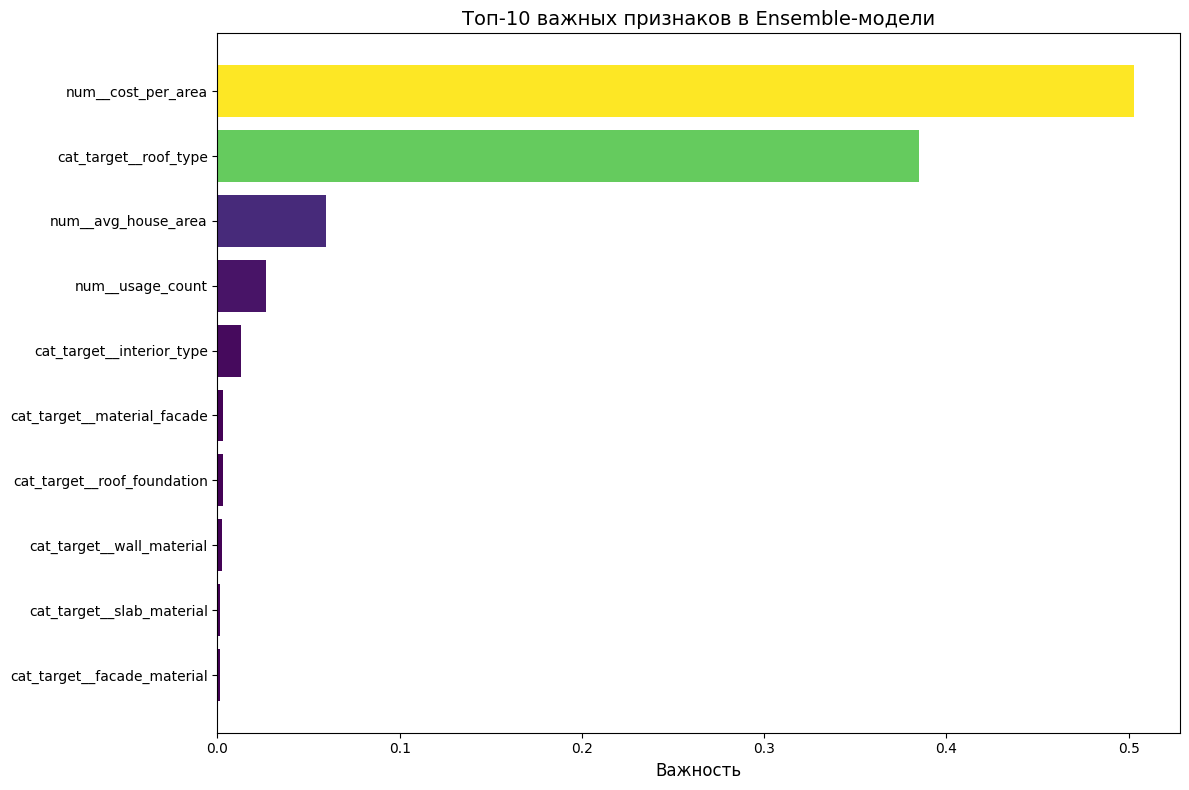

In [118]:
# Извлекаем XGBoost из Ensemble
xgb_from_ensemble = pipeline.named_steps['ensemble'].named_estimators_['xgb']

# Получаем имена признаков после предобработки
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

importance = xgb_from_ensemble.feature_importances_
imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
}).sort_values('importance', ascending=False)

print("ТОП-10 ВАЖНЫХ ПРИЗНАКОВ:")
print(imp_df.head(10))

# Красивый график
plt.figure(figsize=(12, 8))
colors = plt.cm.viridis(imp_df['importance'] / imp_df['importance'].max())
plt.barh(imp_df.head(10)['feature'], imp_df.head(10)['importance'], color=colors)
plt.xlabel('Важность', fontsize=12)
plt.title('Топ-10 важных признаков в Ensemble-модели', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()